# COMP6010 C2 — Continue the cat model to 50 epochs

Your five-epoch pilot passed the implementation checks. Training velocity MSE fell from 0.95002 to
0.49328 and held-out MSE from 0.70106 to 0.47957. The epoch-5 grids show cleaner strokes than epoch 1,
but most outputs remain ambiguous. Lower loss alone is not evidence of recognisable cat generation.

This experiment tests **longer training with the same model and data**. It starts from your epoch-5
model and optimiser and trains epochs 6–50. It keeps the original 2,400/600 split, AdamW settings,
819,521-parameter architecture and all 16 generation seeds.

The main comparisons are epoch 5 versus epoch 50 (both 50 Euler steps), and 20 versus 50 Euler steps
at epoch 50. These settings are chosen before seeing the extended-run outputs. Fifty epochs is an
experiment budget, not a guarantee of good images. Checkpoints at 15 and 30 also preserve progress.

Open this notebook in Colab with a GPU if available. The original Drive folder cat_pilot_v1 is read
as the starting source. A **separate cat_main_v1 folder** holds the extended run, preserving your pilot.
If that original folder is unavailable, the setup cell can restore your uploaded pilot ZIP.

Fill the prediction fields before training. The assistant-proposed hypotheses are labelled as such;
record whether you accept or revise them. The notebook has no invented main-run results.
Its verification metadata describes local code checks, not a completed 50-epoch experiment.

## 1. Research questions and model — method

**Goal:** generate new 28×28 grayscale cat drawings. A single category is allowed by C2, so this model is
unconditional within the cat category; it does not take prompts or class labels and cannot choose another animal.

1. With everything else fixed, does longer training improve cat recognisability?
2. At a fixed checkpoint, how does reducing Euler sampling steps affect recognisability and sampling time?

For a real image $x_1$, independent Gaussian noise $x_0\sim\mathcal N(0,I)$, and $t\sim U(0,1)$:
$$x_t=(1-t)x_0+tx_1,\qquad u_t=x_1-x_0.$$

Train a time-dependent velocity network $v_\phi(x_t,t)$ with mean-squared error:
$$\mathcal L(\phi)=\mathbb E_{x_0,x_1,t}
\left[\frac1d\|v_\phi(x_t,t)-(x_1-x_0)\|_2^2\right],\quad d=28\cdot28.$$

The pair-specific target is a straight-line velocity. Because the network sees only $(x_t,t)$, regression
learns the conditional average of these velocities at each location/time. We do not provide the target
image to the network during generation.

Generate by solving $dx/dt=v_\phi(x,t)$ from fresh Gaussian noise at t=0 to t=1. Euler integration with K steps is
$$x_{k+1}=x_k+\frac1K v_\phi(x_k,k/K).$$
Each Euler step uses one network evaluation, so NFE=K. We do not clamp intermediate states; display clipping
is applied only to final/visualised images and the unclipped arrays are also saved.
The solver is deterministic for a fixed initial noise and model; different noise seeds still produce random samples.

**Connection to COMP6010:** the Gaussian base and interpolation are specified probabilistic structure;
the velocity field is the unknown component learned from data; generation transforms samples from the base.
This is flow matching, not a diffusion reverse-noising loop.

Reference: Lipman et al., [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747).
Use your unit's diffusion/flow-matching lectures as the primary teaching reference.

In [1]:
# SETTINGS: continue the existing model; keep these fixed for the first extended run.
SAVE_TO_DRIVE=True
RUN_NAME='cat_main_v1'
SOURCE_RUN_NAME='cat_pilot_v1'
SOURCE_EPOCH=5
N_SELECTED=3000
TRAIN_FRACTION=0.8
SPLIT_SEED=6010
TRAIN_SEED=2026
EPOCHS=50
EARLY_EPOCH=5
BATCH_SIZE=64
LEARNING_RATE=2e-4
WEIGHT_DECAY=1e-4
GENERATION_SEEDS=list(range(9001,9017))  # Fixed BEFORE seeing images; all 16 are retained.
BASELINE_STEPS=50
VARIANT_STEPS=20
RUN_TRAINING=True   # False: reproduce generation from already saved checkpoint files.
RESUME=True
SAVE_EPOCHS=[5,15,30,50]
TIMING_REPEATS=3
PREDICTION_TRAINING=''  # Write your prediction before training.
PREDICTION_STEPS=''     # Write your prediction before generating comparisons.
PREDICTION_CONTEXT=''   # Date; whether you already saw related outputs; rationale.
PROPOSED_TRAINING_HYPOTHESIS='Longer training may improve coherent cat features over epoch 5; recognisability must be judged from all outputs, not loss.'
PROPOSED_STEPS_HYPOTHESIS='Twenty Euler steps should reduce sampling cost; its quality effect is uncertain and will be tested at the same checkpoint.'

In [2]:
from pathlib import Path
from datetime import datetime,timezone
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import shutil
import sys
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader,TensorDataset

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4,os.cpu_count() or 1))
torch.manual_seed(TRAIN_SEED)
np.random.seed(TRAIN_SEED)
if DEVICE.type=='cuda':
    torch.cuda.manual_seed_all(TRAIN_SEED)
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=True
VERSIONS={k:importlib.metadata.version(k) for k in ['torch','numpy','pandas','matplotlib']}
print('Device:',DEVICE)
print('Hardware:',torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else platform.processor())
print('Packages:',VERSIONS)
if DEVICE.type=='cpu':
    print('CPU detected. This works, but a Colab GPU is preferable for the pilot.')
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE=Path('/content/drive/MyDrive/COMP6010')
else:
    BASE=Path.cwd()/'COMP6010'
RUN=BASE/RUN_NAME
RUN.mkdir(parents=True,exist_ok=True)
CACHE=Path('/content/comp6010_data') if Path('/content').exists() else Path.cwd()/'comp6010_data'
CACHE.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi':120,'font.size':10})
print('Results/checkpoints:',RUN)

# Initialise a new main run from the named pilot checkpoint, never from a later accidental state.
def initialise_from_pilot():
    if (RUN/'last_checkpoint.pt').exists():
        print('Existing main-run checkpoint found; the training cell will validate and resume it.')
        return
    source_root=BASE/SOURCE_RUN_NAME
    checkpoint_name=f'checkpoint_epoch_{SOURCE_EPOCH}.pt'
    if not (source_root/checkpoint_name).exists():
        try:
            from google.colab import files
        except ImportError:
            raise FileNotFoundError(f'Place your extracted pilot at {source_root} first.')
        print('Upload cat_pilot_v1_results.zip to restore the starting checkpoint.')
        uploads=files.upload()
        from zipfile import ZipFile
        import io
        archives=[v for k,v in uploads.items() if k.lower().endswith('.zip')]
        if len(archives)!=1:
            raise ValueError('Upload exactly one pilot results ZIP.')
        source_root=BASE/(SOURCE_RUN_NAME+'_restored')
        source_root.mkdir(exist_ok=True)
        with ZipFile(io.BytesIO(archives[0])) as z:
            for member in z.infolist():
                p=Path(member.filename)
                if p.is_absolute() or '..' in p.parts:
                    raise ValueError('Unexpected path in ZIP.')
            z.extractall(source_root)
    checkpoint=torch.load(source_root/checkpoint_name,map_location='cpu',weights_only=True)
    assert checkpoint['epoch']==SOURCE_EPOCH
    assert len(checkpoint['history'])==SOURCE_EPOCH
    assert 'optimizer' in checkpoint and 'training_id' in checkpoint
    # Only seed this newly created run. Preserve the source run's files.
    shutil.copy2(source_root/checkpoint_name,RUN/'last_checkpoint.pt')
    shutil.copy2(source_root/checkpoint_name,RUN/checkpoint_name)
    pd.DataFrame(checkpoint['history']).to_csv(RUN/'training_history.csv',index=False)
    audit=RUN/'pilot_provenance'
    audit.mkdir(exist_ok=True)
    for filename in ['configuration.json','data_source.json','data_manifest.csv','predictions_epoch_5.json']:
        if (source_root/filename).exists():
            shutil.copy2(source_root/filename,audit/filename)
    (RUN/'continuation_source.json').write_text(json.dumps({
        'source_checkpoint':checkpoint_name,'source_epoch':SOURCE_EPOCH,
        'source_checkpoint_sha256':hashlib.sha256((source_root/checkpoint_name).read_bytes()).hexdigest(),
        'source_training_id':checkpoint['training_id'],
        'created_utc':datetime.now(timezone.utc).isoformat()},indent=2))
    print(f'Initialised separate main run from pilot epoch {SOURCE_EPOCH}; original pilot preserved.')

initialise_from_pilot()


Device: cuda
Hardware: Tesla T4
Packages: {'torch': '2.11.0+cu128', 'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0'}
Mounted at /content/drive
Results/checkpoints: /content/drive/MyDrive/COMP6010/cat_main_v1
Initialised separate main run from pilot epoch 5; original pilot preserved.


## 2. Data, split and inspection

Use Google's centred 28×28 [Quick, Draw! NumPy bitmaps](https://github.com/googlecreativelab/quickdraw-dataset).
The data are provided by Google under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
Credit Google and the dataset in the report. Record these changes: random subsetting, exact-duplicate
removal, fixed train/held-out split, and intensity normalisation; no augmentation or aesthetic filtering.

The script selects 3,000 random original row indices without replacement. It removes exact duplicate
bitmaps within that selected subset before the 80/20 split, records every selected row and exclusion,
and verifies no identical bitmap crosses the split. It does not filter using recognisability or the
game's recognition flag. Some drawings may be ambiguous; inspect and disclose this.

The held-out set is used only for velocity-loss monitoring, never for gradient updates. Once inspected
for tuning, it is an evaluation/validation set, not an untouched final test set.
The full source file is identified by URL and SHA-256; bitmap row indices are not raw vector key IDs.

In [3]:
DATA_URL='https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy'
DATA_FILE=CACHE/'cat.npy'
def sha256_file(path):
    digest=hashlib.sha256()
    with open(path,'rb') as handle:
        for block in iter(lambda:handle.read(1024*1024),b''):
            digest.update(block)
    return digest.hexdigest()

if not DATA_FILE.exists():
    temporary=DATA_FILE.with_suffix('.download')
    print('Downloading the public cat bitmap file...')
    with urllib.request.urlopen(DATA_URL,timeout=120) as response,open(temporary,'wb') as handle:
        shutil.copyfileobj(response,handle)
    # Validate before naming the cache file as complete.
    check=np.load(temporary,mmap_mode='r',allow_pickle=False)
    assert check.ndim==2 and check.shape[1]==784
    del check
    os.replace(temporary,DATA_FILE)
source_hash=sha256_file(DATA_FILE)
all_images=np.load(DATA_FILE,mmap_mode='r',allow_pickle=False)
assert all_images.dtype==np.uint8 and all_images.shape[1]==784
split_rng=np.random.default_rng(SPLIT_SEED)
selected_indices=split_rng.choice(len(all_images),size=N_SELECTED,replace=False)
bitmaps=np.array(all_images[selected_indices])
hashes=[hashlib.sha256(row.tobytes()).hexdigest() for row in bitmaps]
seen=set()
keep=[]
for i,h in enumerate(hashes):
    if h not in seen:
        seen.add(h)
        keep.append(i)
keep=np.array(keep,dtype=int)
permuted=split_rng.permutation(keep)
cut=int(TRAIN_FRACTION*len(permuted))
train_positions,eval_positions=permuted[:cut],permuted[cut:]
assert len(train_positions)>BATCH_SIZE and len(eval_positions)>0
split_labels=np.full(N_SELECTED,'excluded_exact_duplicate',dtype=object)
split_labels[train_positions]='train'
split_labels[eval_positions]='held_out'
manifest=pd.DataFrame({'source_row_index':selected_indices,'bitmap_sha256':hashes,'split':split_labels})
assert not set(manifest.loc[manifest.split=='train','bitmap_sha256']) & set(manifest.loc[manifest.split=='held_out','bitmap_sha256'])
manifest.to_csv(RUN/'data_manifest.csv',index=False)
data_info={'source_url':DATA_URL,'source_sha256':source_hash,'source_rows':len(all_images),
           'category':'cat','license':'CC BY 4.0','selected_original_rows':N_SELECTED,
           'duplicates_removed':N_SELECTED-len(keep),'train_originals':len(train_positions),
           'held_out_originals':len(eval_positions),'split_seed':SPLIT_SEED,
           'preprocessing':'uint8/127.5 - 1; reshape to 1x28x28; no augmentation; no aesthetic filtering'}
(RUN/'data_source.json').write_text(json.dumps(data_info,indent=2))
train_x=torch.from_numpy(bitmaps[train_positions].astype(np.float32)/127.5-1).reshape(-1,1,28,28)
eval_x=torch.from_numpy(bitmaps[eval_positions].astype(np.float32)/127.5-1).reshape(-1,1,28,28)
print(json.dumps(data_info,indent=2))
print('Tensor shapes:',train_x.shape,eval_x.shape)

{
  "source_url": "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy",
  "source_sha256": "21a281839d3f2eef601d57d2338a4eafdf24649f8d0a0e42d3ec3e595911463e",
  "source_rows": 123202,
  "category": "cat",
  "license": "CC BY 4.0",
  "selected_original_rows": 3000,
  "duplicates_removed": 0,
  "train_originals": 2400,
  "held_out_originals": 600,
  "split_seed": 6010,
  "preprocessing": "uint8/127.5 - 1; reshape to 1x28x28; no augmentation; no aesthetic filtering"
}
Tensor shapes: torch.Size([2400, 1, 28, 28]) torch.Size([600, 1, 28, 28])


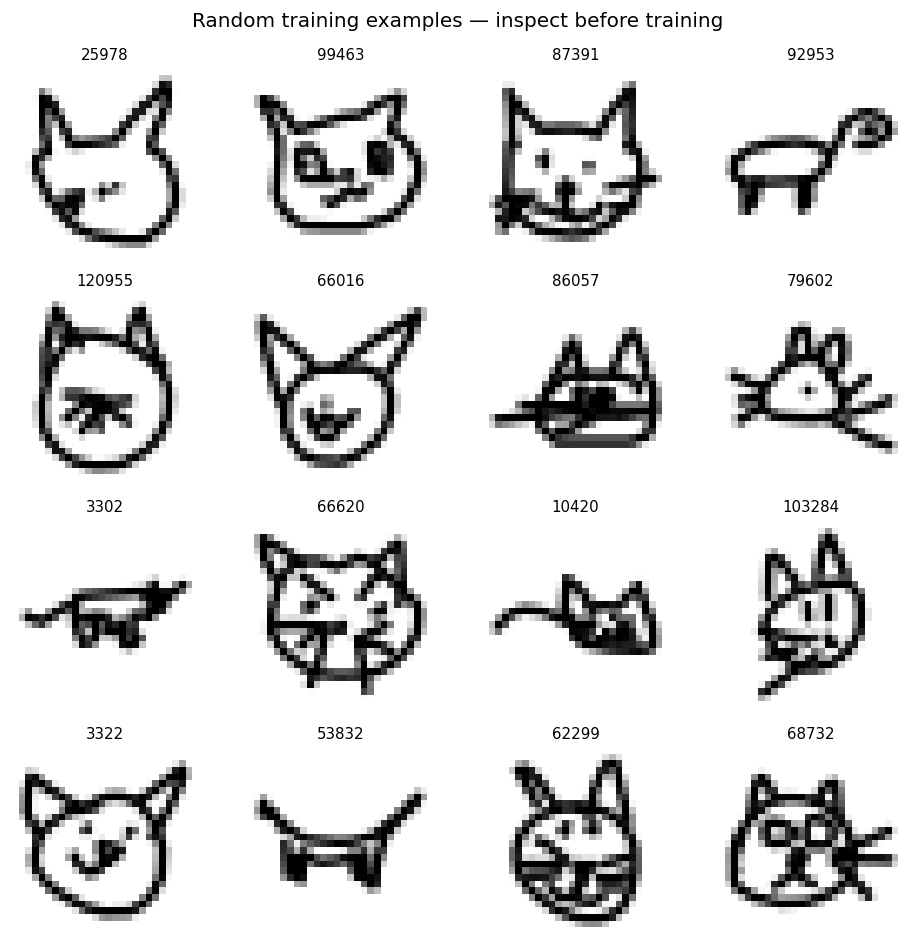

In [4]:
def image_grid(images,path,title,labels=None,columns=4):
    """Display black strokes on white; identical scaling for every comparison."""
    if isinstance(images,torch.Tensor):
        images=images.detach().cpu().numpy()
    rows=math.ceil(len(images)/columns)
    fig,axes=plt.subplots(rows,columns,figsize=(columns*2,rows*2),squeeze=False)
    for i,ax in enumerate(axes.flat):
        ax.axis('off')
        if i<len(images):
            ax.imshow(np.clip((images[i].squeeze()+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1)
            if labels is not None:
                ax.set_title(str(labels[i]),fontsize=9)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path,dpi=160)
    plt.show()

inspection_rng=np.random.default_rng(7001)
inspection_positions=inspection_rng.choice(len(train_x),16,replace=False)
image_grid(train_x[inspection_positions],RUN/'training_data_random_grid.png',
           'Random training examples — inspect before training',
           manifest.iloc[train_positions[inspection_positions]].source_row_index.tolist())

## 3. Velocity network, targets and checks

A small U-Net processes images at 28×28, 14×14 and 7×7. Sinusoidal time features are transformed by an
MLP and added in each residual block. Skip connections carry spatial detail to the upsampling path.
All parameters are trainable; no pretrained weights, autoencoder or text encoder is involved.

The important data flow is:
1. make_training_pair receives clean images [B,1,28,28], draws matching noise and times [B],
   then returns interpolated inputs, times and target velocities.
2. VelocityUNet receives interpolated images and times, returning [B,1,28,28] predicted velocities.
3. MSE compares prediction with target; backward computes gradients and AdamW updates parameters.
4. euler_sample repeatedly calls that same network on generated states, starting from fresh noise.

In [5]:
class TimeEmbedding(nn.Module):
    def __init__(self,dimension=64):
        super().__init__()
        self.register_buffer('frequencies',torch.exp(-math.log(10000)*torch.arange(dimension//2)/(dimension//2-1)))
        self.mlp=nn.Sequential(nn.Linear(dimension,128),nn.SiLU(),nn.Linear(128,128))
    def forward(self,t):
        angles=t[:,None]*self.frequencies[None,:]*1000
        return self.mlp(torch.cat([angles.sin(),angles.cos()],dim=1))

class TimeBlock(nn.Module):
    def __init__(self,input_channels,output_channels):
        super().__init__()
        self.conv1=nn.Conv2d(input_channels,output_channels,3,padding=1)
        self.norm1=nn.GroupNorm(8,output_channels)
        self.time=nn.Linear(128,output_channels)
        self.conv2=nn.Conv2d(output_channels,output_channels,3,padding=1)
        self.norm2=nn.GroupNorm(8,output_channels)
        self.skip=nn.Conv2d(input_channels,output_channels,1) if input_channels!=output_channels else nn.Identity()
    def forward(self,x,time_embedding):
        h=F.silu(self.norm1(self.conv1(x)))
        h=h+self.time(time_embedding)[:,:,None,None]
        h=self.norm2(self.conv2(F.silu(h)))
        return F.silu(h+self.skip(x))

class VelocityUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time=TimeEmbedding()
        self.input=nn.Conv2d(1,32,3,padding=1)
        self.block28=TimeBlock(32,32)
        self.down14=nn.Conv2d(32,64,4,stride=2,padding=1)
        self.block14=TimeBlock(64,64)
        self.down7=nn.Conv2d(64,128,4,stride=2,padding=1)
        self.middle=TimeBlock(128,128)
        self.up14=TimeBlock(128+64,64)
        self.up28=TimeBlock(64+32,32)
        self.output=nn.Conv2d(32,1,3,padding=1)
    def forward(self,x,t):
        embedding=self.time(t)
        skip28=self.block28(self.input(x),embedding)
        skip14=self.block14(self.down14(skip28),embedding)
        h=self.middle(self.down7(skip14),embedding)
        h=self.up14(torch.cat([F.interpolate(h,size=(14,14),mode='nearest'),skip14],dim=1),embedding)
        h=self.up28(torch.cat([F.interpolate(h,size=(28,28),mode='nearest'),skip28],dim=1),embedding)
        return self.output(h)

def make_training_pair(clean):
    noise=torch.randn_like(clean)
    t=torch.rand(len(clean),device=clean.device)
    mixed=(1-t[:,None,None,None])*noise+t[:,None,None,None]*clean
    return mixed,t,clean-noise

# Smoke-check a disposable model, so the check does not change the real training initialisation.
torch.manual_seed(TRAIN_SEED)
probe=VelocityUNet().to(DEVICE)
clean=train_x[:4].to(DEVICE)
mixed,t,target=make_training_pair(clean)
prediction=probe(mixed,t)
assert prediction.shape==target.shape==clean.shape
loss=F.mse_loss(prediction,target)
assert torch.isfinite(loss)
loss.backward()
assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in probe.parameters())
before=next(probe.parameters()).detach().clone()
torch.optim.AdamW(probe.parameters(),lr=LEARNING_RATE).step()
assert not torch.equal(before,next(probe.parameters()).detach())
print('Passed: tensor shapes, finite loss/gradients, all parameters connected, and parameter update.')
del probe,clean,mixed,t,target,prediction,loss
torch.manual_seed(TRAIN_SEED)
model=VelocityUNet().to(DEVICE)
PARAMETER_COUNT=sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Trainable parameters:',PARAMETER_COUNT)

Passed: tensor shapes, finite loss/gradients, all parameters connected, and parameter update.
Trainable parameters: 819521


## 4. Continue training and preserve checkpoints

This experiment continues the existing model from epoch 5 to epoch 50 and keeps epoch 5 for comparison. Keep the subset, split,
architecture, optimiser, learning rate and generation seeds fixed. This comparison changes only training
duration. A later main experiment can extend training after reviewing the pilot.

Write predictions in the settings cell before training. The notebook records them without inventing text.
Checkpoints include optimiser state and epoch history. Resume is deterministic at epoch boundaries for
the same software/hardware settings: each epoch has its own data-order and training RNG seed. CUDA
operations can still differ across hardware/library versions; versions and hardware are recorded.

Held-out loss uses a fixed set of noise/time pairs each epoch for comparability. Loss is a velocity
regression diagnostic, **not an image-quality metric**.

Prediction fields are blank. Complete them honestly before claiming a prediction-versus-observation record.
Resuming after epoch 5
Epoch 6/50: train=0.47195, held-out=0.46156, train seconds=1.2
Rough remaining training time at this speed: 0.9 minutes, plus evaluation/saving.
Epoch 7/50: train=0.46182, held-out=0.45169, train seconds=0.8
Epoch 8/50: train=0.44711, held-out=0.44188, train seconds=0.8
Epoch 9/50: train=0.43868, held-out=0.43222, train seconds=0.8
Epoch 10/50: train=0.43049, held-out=0.42886, train seconds=0.8
Epoch 11/50: train=0.42319, held-out=0.42203, train seconds=0.9
Epoch 12/50: train=0.42099, held-out=0.42413, train seconds=0.9
Epoch 13/50: train=0.41608, held-out=0.41524, train seconds=0.9
Epoch 14/50: train=0.40906, held-out=0.40991, train seconds=0.9
Epoch 15/50: train=0.41102, held-out=0.40543, train seconds=0.8
Epoch 16/50: train=0.40550, held-out=0.40349, train seconds=0.8
Epoch 17/50: train=0.40374, held-out=0.40293, train seconds=0.8
Epoch 18/50: train=0.39

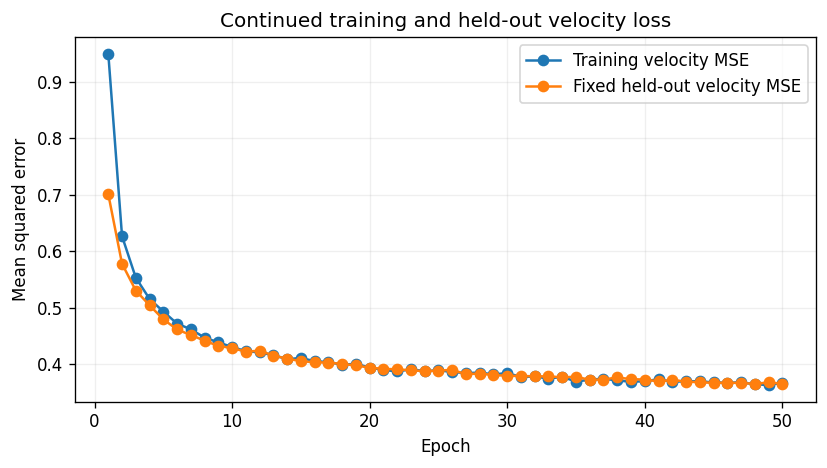

In [6]:
def synchronize():
    if DEVICE.type=='cuda':
        torch.cuda.synchronize()

def atomic_torch_save(payload,path):
    temporary=path.with_suffix('.tmp')
    torch.save(payload,temporary)
    os.replace(temporary,path)

manifest_digest=hashlib.sha256(manifest.to_csv(index=False).encode()).hexdigest()
TRAINING_ID={'architecture':'VelocityUNet_v1_32_64_128','manifest_sha256':manifest_digest,
             'source_sha256':source_hash,'train_seed':TRAIN_SEED,'batch_size':BATCH_SIZE,
             'learning_rate':LEARNING_RATE,'weight_decay':WEIGHT_DECAY}
configuration={**TRAINING_ID,'epochs_requested':EPOCHS,'early_epoch':EARLY_EPOCH,
    'generation_seeds':GENERATION_SEEDS,'baseline_steps':BASELINE_STEPS,'variant_steps':VARIANT_STEPS,
    'timing_repeats':TIMING_REPEATS,'trainable_parameters':PARAMETER_COUNT,'versions':VERSIONS,'python':sys.version,
    'hardware':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else platform.processor(),
    'device':str(DEVICE),'data':data_info}
(RUN/'configuration.json').write_text(json.dumps(configuration,indent=2))
prediction_path=RUN/f'predictions_epoch_{EPOCHS}.json'
if not prediction_path.exists() or not (RUN/'training_history.csv').exists():
    prediction_path.write_text(json.dumps({'recorded_utc':datetime.now(timezone.utc).isoformat(),
        'training_prediction':PREDICTION_TRAINING,'steps_prediction':PREDICTION_STEPS,
        'context':PREDICTION_CONTEXT,
        'assistant_proposed_training_hypothesis':PROPOSED_TRAINING_HYPOTHESIS,
        'assistant_proposed_steps_hypothesis':PROPOSED_STEPS_HYPOTHESIS},indent=2))
if not PREDICTION_TRAINING or not PREDICTION_STEPS:
    print('Prediction fields are blank. Complete them honestly before claiming a prediction-versus-observation record.')

optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
history=[]
start_epoch=0
last_path=RUN/'last_checkpoint.pt'
if RESUME and last_path.exists():
    checkpoint=torch.load(last_path,map_location='cpu',weights_only=True)
    assert checkpoint['training_id']==TRAINING_ID,'Settings/data changed: choose a new RUN_NAME.'
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    # Optimiser tensors must follow parameters onto the active device.
    for state in optimizer.state.values():
        for k,v in state.items():
            if torch.is_tensor(v):
                state[k]=v.to(DEVICE)
    start_epoch=checkpoint['epoch']
    history=checkpoint['history']
    print('Resuming after epoch',start_epoch)

# Fixed held-out interpolation examples; never used for gradients.
evaluation_rng=torch.Generator().manual_seed(8801)
eval_noise=torch.randn(eval_x.shape,generator=evaluation_rng)
eval_t=torch.rand(len(eval_x),generator=evaluation_rng)
eval_mixed=(1-eval_t[:,None,None,None])*eval_noise+eval_t[:,None,None,None]*eval_x
eval_target=eval_x-eval_noise

@torch.no_grad()
def held_out_loss():
    model.eval()
    total=0.0
    for begin in range(0,len(eval_x),BATCH_SIZE):
        end=begin+BATCH_SIZE
        predicted=model(eval_mixed[begin:end].to(DEVICE),eval_t[begin:end].to(DEVICE))
        batch_loss=F.mse_loss(predicted,eval_target[begin:end].to(DEVICE))
        total+=float(batch_loss)*len(predicted)
    return total/len(eval_x)

training_cell_started=time.perf_counter()
if RUN_TRAINING:
    assert 1<=EARLY_EPOCH<=EPOCHS
    for epoch in range(start_epoch+1,EPOCHS+1):
        torch.manual_seed(TRAIN_SEED+epoch)
        if DEVICE.type=='cuda':
            torch.cuda.manual_seed_all(TRAIN_SEED+epoch)
        loader=DataLoader(TensorDataset(train_x),batch_size=BATCH_SIZE,shuffle=True,num_workers=0,
                          generator=torch.Generator().manual_seed(TRAIN_SEED+10000+epoch))
        model.train()
        synchronize()
        started=time.perf_counter()
        loss_sum=0.0
        for (clean_cpu,) in loader:
            clean=clean_cpu.to(DEVICE)
            mixed,t,target=make_training_pair(clean)
            optimizer.zero_grad(set_to_none=True)
            loss=F.mse_loss(model(mixed,t),target)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite loss. Stop and diagnose; do not report this as successful training.')
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            loss_sum+=float(loss.detach())*len(clean)
        synchronize()
        train_seconds=time.perf_counter()-started
        started=time.perf_counter()
        validation_loss=held_out_loss()
        synchronize()
        record={'epoch':epoch,'train_loss':loss_sum/len(train_x),'held_out_loss':validation_loss,
                'train_seconds':train_seconds,'evaluation_seconds':time.perf_counter()-started}
        history.append(record)
        payload={'epoch':epoch,'model':model.state_dict(),'optimizer':optimizer.state_dict(),
                 'history':history,'training_id':TRAINING_ID}
        atomic_torch_save(payload,last_path)
        if epoch in set(SAVE_EPOCHS+[EARLY_EPOCH,EPOCHS]):
            atomic_torch_save(payload,RUN/f'checkpoint_epoch_{epoch}.pt')
        pd.DataFrame(history).to_csv(RUN/'training_history.csv',index=False)
        print(f"Epoch {epoch}/{EPOCHS}: train={record['train_loss']:.5f}, held-out={validation_loss:.5f}, train seconds={train_seconds:.1f}")
        if epoch==start_epoch+1:
            print(f'Rough remaining training time at this speed: {train_seconds*(EPOCHS-epoch)/60:.1f} minutes, plus evaluation/saving.')
else:
    print('Training disabled: use existing checkpoint_epoch files for generation.')

(RUN/'latest_training_session.json').write_text(json.dumps({'requested_final_epoch':EPOCHS,
    'starting_epoch':start_epoch,'training_enabled':RUN_TRAINING,
    'training_evaluation_checkpoint_wall_seconds':time.perf_counter()-training_cell_started},indent=2))
assert (RUN/f'checkpoint_epoch_{EARLY_EPOCH}.pt').exists(),'Required early checkpoint is missing.'
assert (RUN/f'checkpoint_epoch_{EPOCHS}.pt').exists(),'Required final checkpoint is missing.'
history_frame=pd.read_csv(RUN/'training_history.csv')
fig,ax=plt.subplots(figsize=(7,4))
ax.plot(history_frame.epoch,history_frame.train_loss,'o-',label='Training velocity MSE')
ax.plot(history_frame.epoch,history_frame.held_out_loss,'o-',label='Fixed held-out velocity MSE')
ax.set(xlabel='Epoch',ylabel='Mean squared error',title='Continued training and held-out velocity loss')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(RUN/'loss_curve.png',dpi=180)
plt.show()

## 5. Controlled generation comparisons

| Configuration | Checkpoint | Euler steps / NFE |
|---|---|---|
| Baseline | Epoch 50 | 50 |
| Training variant | Epoch 5 | 50 |
| Inference variant | Epoch 50 | 20 |

The code reads actual epochs from settings if the main run later changes them. Each configuration uses
the **same 16 predetermined Gaussian seeds**, so it generates 48 total outputs. Keep all images, including
failures. No prompts or class balancing are needed for this single-category model.
Timing covers the complete 16-image batch with GPU synchronisation, after one untimed complete solve for that configuration. Three complete solves are timed; all durations are saved and their median is reported. It excludes
model loading, initial-noise construction, file saving and figures. Batch time/16 is an amortised cost,
not the latency of generating one image alone. Small timing differences can be noisy.

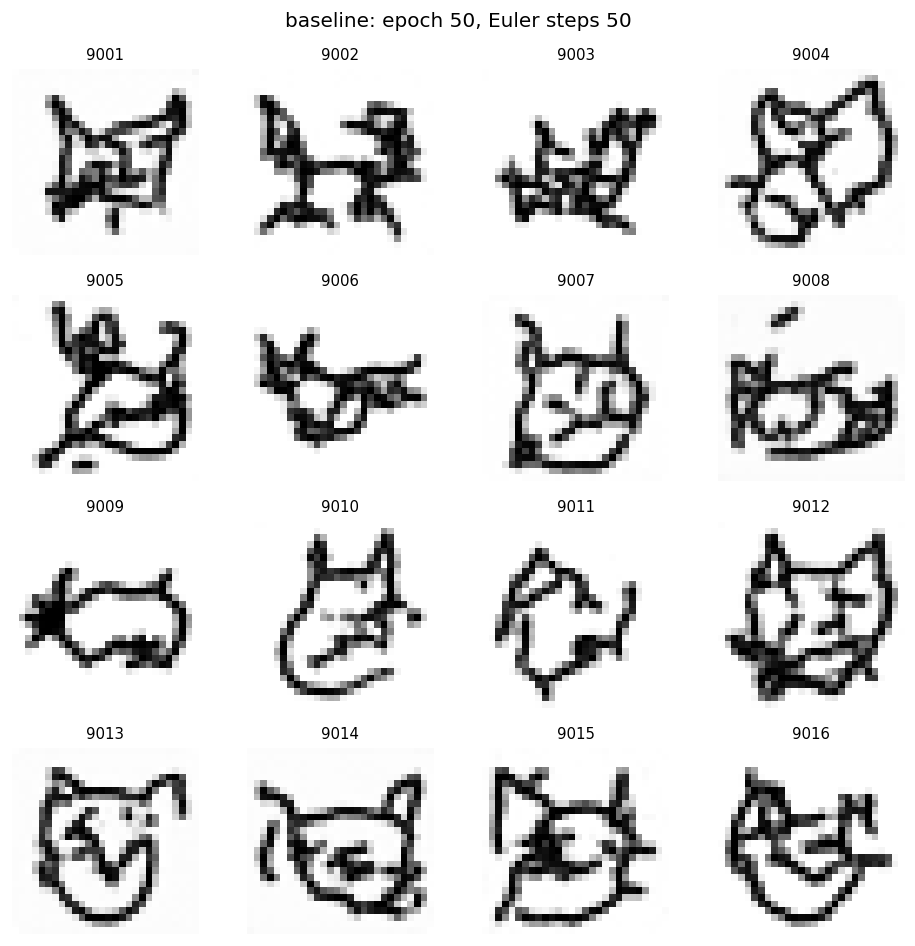

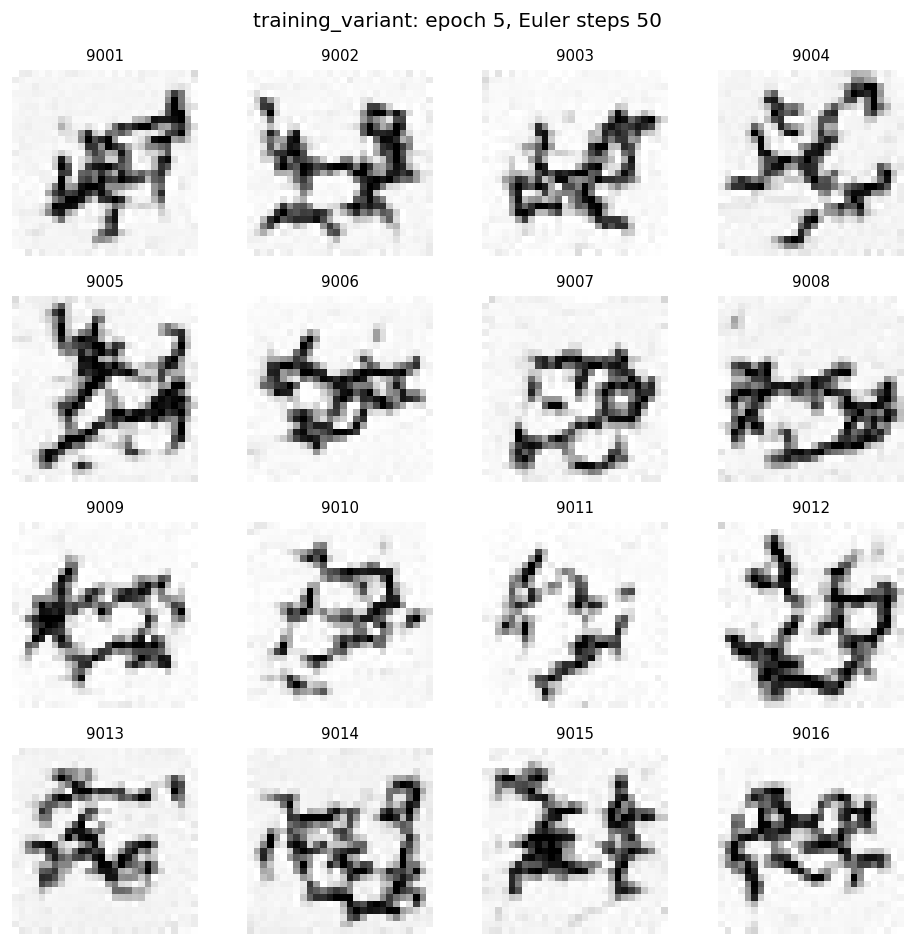

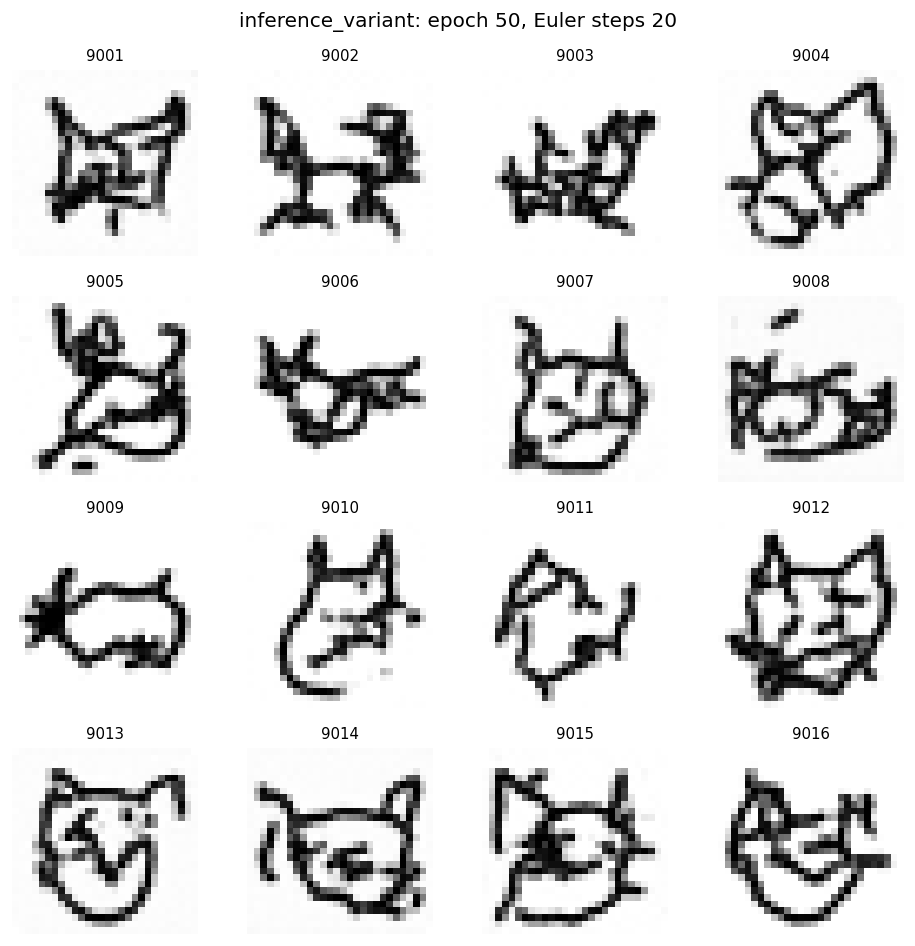

    configuration  epoch  euler_steps  nfe_per_image  images  sampling_batch_seconds sampling_seconds_statistic  sampling_repeats  sampling_seconds_std  amortised_seconds_per_image  training_seconds_to_checkpoint  fraction_pixels_outside_training_range
         baseline     50           50             50      16                0.216137                     median                 3              0.019345                     0.013509                       45.837728                                0.344069
 training_variant      5           50             50      16                0.141011                     median                 3              0.002041                     0.008813                        4.465072                                0.083386
inference_variant     50           20             20      16                0.056858                     median                 3              0.005979                     0.003554                       45.837728                             

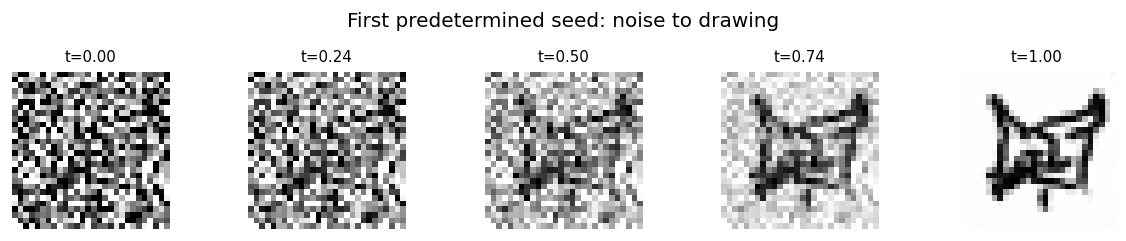

In [7]:
@torch.no_grad()
def euler_sample(network,initial_noise,steps,save_states=False):
    if steps<1:
        raise ValueError('steps must be positive')
    network.eval()
    x=initial_noise.clone()
    keep={0,steps//4,steps//2,3*steps//4,steps}
    states={0:x.detach().cpu()} if save_states else {}
    for k in range(steps):
        t=torch.full((len(x),),k/steps,device=x.device)
        x=x+network(x,t)/steps
        if save_states and k+1 in keep:
            states[k+1]=x.detach().cpu()
    return x,states

# Independent integration check: a constant velocity has an exact solution.
class ConstantVelocity(nn.Module):
    def forward(self,x,t):
        return torch.ones_like(x)*0.25
fixture=torch.zeros(2,1,28,28,device=DEVICE)
solution,_=euler_sample(ConstantVelocity().to(DEVICE),fixture,10)
assert torch.allclose(solution,fixture+0.25,atol=1e-6)

initial_noise=torch.cat([torch.randn(1,1,28,28,generator=torch.Generator().manual_seed(seed))
                         for seed in GENERATION_SEEDS]).to(DEVICE)
CONFIGURATIONS=[('baseline',EPOCHS,BASELINE_STEPS),('training_variant',EARLY_EPOCH,BASELINE_STEPS),
                ('inference_variant',EPOCHS,VARIANT_STEPS)]
EVAL=RUN/f'evaluation_final{EPOCHS}_early{EARLY_EPOCH}_steps{BASELINE_STEPS}_{VARIANT_STEPS}'
EVAL.mkdir(exist_ok=True)
timing_records=[]
generation_records=[]
generated={}
for name,epoch,steps in CONFIGURATIONS:
    checkpoint=torch.load(RUN/f'checkpoint_epoch_{epoch}.pt',map_location='cpu',weights_only=True)
    assert checkpoint['training_id']==TRAINING_ID
    model.load_state_dict(checkpoint['model'])
    model.eval()
    # One full untimed solve warms this configuration; time all three subsequent solves.
    euler_sample(model,initial_noise,steps)
    measured=[]
    for repeat in range(TIMING_REPEATS):
        synchronize()
        started=time.perf_counter()
        output,_=euler_sample(model,initial_noise,steps)
        synchronize()
        elapsed_repeat=time.perf_counter()-started
        measured.append(elapsed_repeat)
        timing_records.append({'configuration':name,'epoch':epoch,'steps':steps,
                               'repeat':repeat+1,'batch_seconds':elapsed_repeat})
    elapsed=float(np.median(measured))

    assert torch.isfinite(output).all()
    generated[name]=output.cpu()
    np.save(EVAL/f'{name}_unclipped.npy',output.cpu().numpy())
    image_grid(output,EVAL/f'{name}_16_samples.png',f'{name}: epoch {epoch}, Euler steps {steps}',GENERATION_SEEDS)
    generation_records.append({'configuration':name,'epoch':epoch,'euler_steps':steps,'nfe_per_image':steps,
        'images':len(output),'sampling_batch_seconds':elapsed,'sampling_seconds_statistic':'median',
        'sampling_repeats':TIMING_REPEATS,'sampling_seconds_std':float(np.std(measured,ddof=1)),'amortised_seconds_per_image':elapsed/len(output),
        'training_seconds_to_checkpoint':float(history_frame.loc[history_frame.epoch<=epoch,'train_seconds'].sum()),
        'fraction_pixels_outside_training_range':float(((output<-1)|(output>1)).float().mean())})
generation_table=pd.DataFrame(generation_records)
pd.DataFrame(timing_records).to_csv(EVAL/'sampling_timing_repeats.csv',index=False)
generation_table.to_csv(EVAL/'generation_settings_and_times.csv',index=False)
print(generation_table.to_string(index=False))

# Visualise the transformation for the FIRST seed, not a handpicked success.
model.load_state_dict(torch.load(RUN/f'checkpoint_epoch_{EPOCHS}.pt',map_location='cpu',weights_only=True)['model'])
_,trajectory=euler_sample(model,initial_noise[:1],BASELINE_STEPS,save_states=True)
image_grid(torch.cat(list(trajectory.values())),EVAL/'noise_to_drawing.png','First predetermined seed: noise to drawing',
           [f't={k/BASELINE_STEPS:.2f}' for k in trajectory],columns=5)

## 6. Quality, diversity and possible memorisation

Score **every one of the 48 outputs**, not just attractive images. Use this fixed cat-recognisability rubric:

- 0: blank, noise, or no identifiable animal structure.
- 1: possible animal or cat-like fragments, but ambiguous overall.
- 2: recognisable cat with coherent head/body structure and distinguishing cat features.

Enter a 0/1/2 score and a short observation in quality_scores.csv inside the evaluation folder printed below. The quality measure is the proportion
scoring 2, with mean score as an additional summary. This is subjective, category-aware self-assessment,
not an independent classifier or proof of perceptual quality. Apply the same rubric to every configuration.
Score the full set even when the pilot fails. Do not infer recognisability from training loss.

The nearest-neighbour panel uses pixel MSE against **all training images** for each baseline output.
Inspect these and discuss several examples. Background dominance and small translations limit pixel MSE;
the closest pixel match may not be the closest perceptual match. Similarity alone does not prove copying.
Pairwise pixel distances across generated images are a rough diversity diagnostic, not a semantic diversity score.

Scoring CSV: /content/drive/MyDrive/COMP6010/cat_main_v1/evaluation_final50_early5_steps50_20/quality_scores.csv


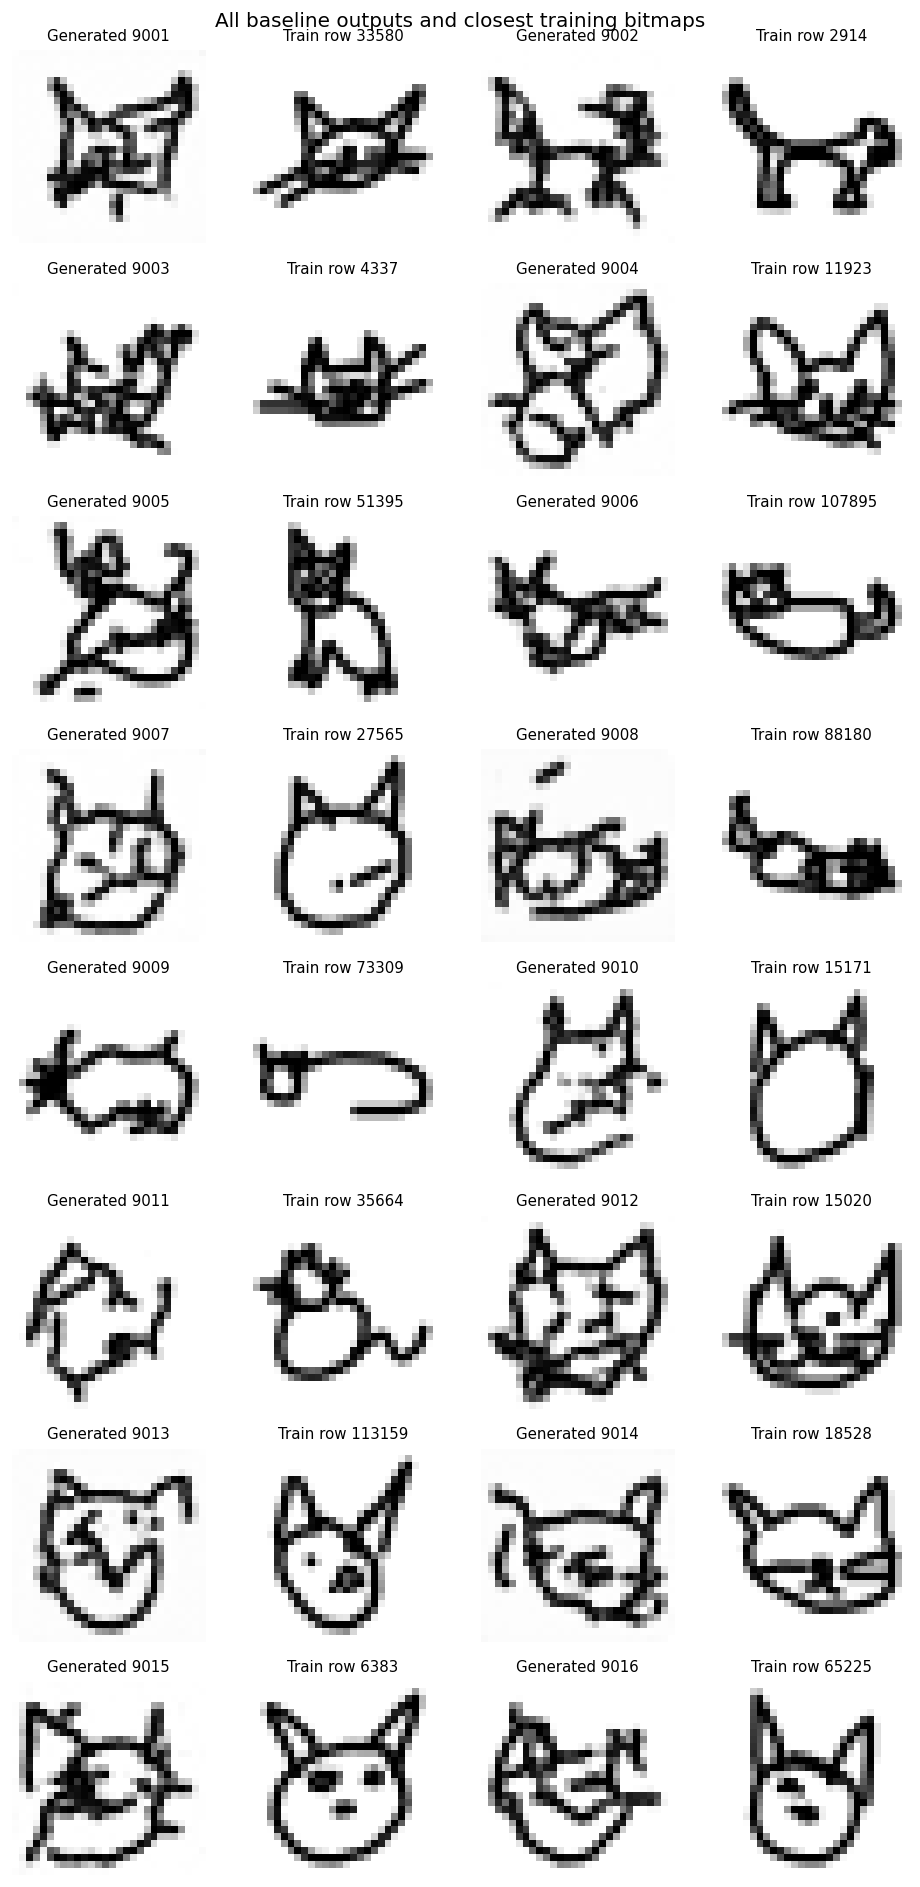

Quality scoring unfinished: 0/48. Complete quality_scores.csv using the rubric.


In [8]:
score_path=EVAL/'quality_scores.csv'
print('Scoring CSV:',score_path)
if not score_path.exists():
    pd.DataFrame([{'configuration':name,'seed':seed,'cat_score':'','notes':''}
                  for name,_,_ in CONFIGURATIONS for seed in GENERATION_SEEDS]).to_csv(score_path,index=False)

flat_train=train_x.flatten(1)
baseline=generated['baseline'].clamp(-1,1).flatten(1)
# Compute distance in chunks; never allocate a [16,train_count,784] difference tensor.
nearest_indices=[]
nearest_mse=[]
for sample in baseline:
    squared=((flat_train-sample)**2).mean(dim=1)
    idx=int(squared.argmin())
    nearest_indices.append(idx)
    nearest_mse.append(float(squared[idx]))
nearest_table=pd.DataFrame({'seed':GENERATION_SEEDS,
    'nearest_training_source_row':selected_indices[train_positions[np.array(nearest_indices)]],
    'pixel_mse':nearest_mse})
nearest_table.to_csv(EVAL/'nearest_training_matches.csv',index=False)
paired=[]
labels=[]
for i,idx in enumerate(nearest_indices):
    paired.extend([generated['baseline'][i],train_x[idx]])
    labels.extend([f'Generated {GENERATION_SEEDS[i]}',f'Train row {nearest_table.iloc[i].nearest_training_source_row:.0f}'])
image_grid(torch.stack(paired),EVAL/'nearest_training_pairs.png','All baseline outputs and closest training bitmaps',labels,columns=4)

diagnostics=[]
for name,images in generated.items():
    flat=images.clamp(-1,1).flatten(1)
    distances=torch.pdist(flat,p=2)**2/flat.shape[1]
    diagnostics.append({'configuration':name,'mean_pairwise_pixel_mse':float(distances.mean()),
                        'minimum_pairwise_pixel_mse':float(distances.min())})
pd.DataFrame(diagnostics).to_csv(EVAL/'diversity_diagnostics.csv',index=False)

# After entering scores in the CSV, rerun this cell to produce the quality summary.
scores=pd.read_csv(score_path)
scores['cat_score']=pd.to_numeric(scores.cat_score,errors='coerce')
expected={(name,seed) for name,_,_ in CONFIGURATIONS for seed in GENERATION_SEEDS}
assert set(zip(scores.configuration,scores.seed))==expected and len(scores)==48
scored=scores.cat_score.notna()
assert scores.loc[scored,'cat_score'].isin([0,1,2]).all(),'Scores must be 0, 1 or 2.'
if scored.all():
    scores['recognisable']=(scores.cat_score==2).astype(float)
    quality=scores.groupby('configuration').agg(mean_score=('cat_score','mean'),
        recognisable_fraction=('recognisable','mean'),number_scored=('cat_score','count'))
    quality.to_csv(EVAL/'quality_summary.csv')
    print(quality)
else:
    print(f'Quality scoring unfinished: {int(scored.sum())}/48. Complete quality_scores.csv using the rubric.')

## 7. Interpret and decide what to do next

Before extending training, inspect data and every output grid. Record:
- Whether loss stays finite and broadly decreases, and whether held-out loss behaves differently.
- Recognisability scores and obvious failures across the full matched output sets.
- Whether epoch 50 improves on epoch 5 at fixed 50 steps.
- Whether 20 versus 50 steps changes quality or sampling time at the same checkpoint.
- Variation between seeds and any repeated structures or unusually close training matches.
- At least one failed expectation or limitation, including the small dataset and short pilot.

If quality is weak, that is a pilot finding. Do not claim that decreasing loss proves successful image generation.
Share the notebook and results ZIP for diagnosis before changing multiple settings.

For a later main run, increasing EPOCHS with the same RUN_NAME resumes the same training sequence;
keep data/model/optimiser settings unchanged. Retain the earlier checkpoint used for comparison.
Never reuse the same folder for different model/data settings. An inference-only route is RUN_TRAINING=False
with matching configuration and the saved named checkpoints, which avoids retraining.

In [9]:
# Enter one score per seed, ordered 9001...9016, after inspecting ALL 16 images in each grid.
# Example shape: [0,1,1,0,...] with exactly 16 entries. Do not copy an example as your ratings.
MY_SCORES={'baseline':[], 'training_variant':[], 'inference_variant':[]}
RATER_AND_DATE=''  # Your name/initials and actual scoring date.
RATING_CONTEXT=''  # Note that the category is known; mention any AI assistance.
if any(MY_SCORES.values()):
    assert RATER_AND_DATE.strip(),'Record the rater and date.'
    assert all(len(values)==16 and all(v in (0,1,2) for v in values) for values in MY_SCORES.values())
    scores=pd.read_csv(score_path)
    for name,values in MY_SCORES.items():
        for seed,score in zip(GENERATION_SEEDS,values):
            scores.loc[(scores.configuration==name)&(scores.seed==seed),'cat_score']=score
    scores.to_csv(score_path,index=False)
    scores['recognisable']=(scores.cat_score==2).astype(float)
    quality=scores.groupby('configuration').agg(mean_score=('cat_score','mean'),
        recognisable_fraction=('recognisable','mean'),number_scored=('cat_score','count'))
    quality.to_csv(EVAL/'quality_summary.csv')
    (EVAL/'rating_provenance.json').write_text(json.dumps({'rater_date':RATER_AND_DATE,
        'context':RATING_CONTEXT,'rubric':'0 none; 1 ambiguous animal/cat fragments; 2 recognisable cat'},indent=2))
    print(quality)
else:
    print('Leave this cell blank for an initial technical run; complete ratings before reporting quality.')

Leave this cell blank for an initial technical run; complete ratings before reporting quality.


In [10]:
# Package evidence; omit the large public data cache.
(RUN/'requirements_observed.txt').write_text('\n'.join(f'{k}=={v}' for k,v in VERSIONS.items())+'\n')
(RUN/'README.txt').write_text("""COMP6010 C2 continued training reproduction

Open COMP6010_Part_C2_Main_Experiment.ipynb and run cells in order.
Dependencies: torch, numpy, pandas, matplotlib (installed versions recorded).
Public data acquisition URL and SHA-256 are in data_source.json.
Training/evaluation original row indices, bitmap hashes and duplicate exclusions are in data_manifest.csv.
Preprocessing: uint8 / 127.5 - 1, reshape to 1x28x28; no augmentation or aesthetic filtering.
Data: Google Quick, Draw!, CC BY 4.0. Source: https://github.com/googlecreativelab/quickdraw-dataset
Method reference: Lipman et al., Flow Matching for Generative Modeling, https://arxiv.org/abs/2210.02747
This notebook implements a small original educational PyTorch pipeline with AI assistance; cite that assistance.

Training: RUN_TRAINING=True. Continue from epoch 5 to 50, batch 64, AdamW lr 0.0002, weight decay 0.0001.
Epoch checkpoints include model, optimiser, settings and history; last_checkpoint.pt supports epoch-boundary resume.
Inference: RUN_TRAINING=False with saved named checkpoints and matching settings; run the other cells in order.
The data acquisition route is still needed for the split and nearest-training evidence.
GPU recommended; use the printed first-epoch duration to estimate remaining time.
Compute-only training and evaluation times are in training_history.csv; latest session wall time includes checkpoint saving; generation times/NFE in generation_settings_and_times.csv (median of 3 full-solve repeats; raw repeats also saved).

Each evaluation_final... subfolder preserves a comparison set and its own human scores.
Baseline and variants use the same 16 fixed seeds. All 48 outputs and unclipped arrays are retained.
noise_to_drawing.png uses the first predetermined seed. nearest_training_pairs.png shows all baseline nearest matches.
quality_scores.csv requires human completion; quality_summary.csv appears only when all 48 scores are valid.
Training loss is not an image-quality metric. Pixel-MSE diversity/matches have background/translation limitations.

This is an extended experiment, not a finished Part C report. Include the executed notebook separately in the final supplement.
Record method, all settings, quality results, timings, failures, limitations, memorisation discussion and AI-use record.
No full public dataset or pretrained base model is included in this ZIP.
""")
log=RUN/'ai_use_log.md'
if not log.exists():
    log.write_text("""# C2 AI-use and development record

- Date/tool/model: [enter actual date and visible model label].
- User prompt: 'check this colab run output and continue'
- Assistance: guided flow-matching pilot design and code; explanations of interpolation, velocity loss and Euler integration.
- Selected response excerpt: 'It will save checkpoints and generate matched outputs for the training-duration and sampling-step comparisons, so we can assess quality before committing to a longer run.'
- My independent source check: [compare equations with unit lectures and the original flow-matching paper].
- My code check: [inspect actual shapes, gradients, update test and constant-velocity solver test].
- Prediction before running: [see saved prediction JSON; add rationale, do not backdate].
- Observation with evidence: [specific loss, image score, timing or failure].
- Decision/change: [accept/reject advice based on evidence].
- Limitation or failed expectation: [complete].

Combine with selected Part A/B interactions to keep 3–5 interactions for the whole assignment.
Assistant checks are not a substitute for your own understanding or personal verification.
""")
# A persistent ZIP beside the run folder contains only this run's evidence and small checkpoints.
archive=shutil.make_archive(str(BASE/f'{RUN_NAME}_results'),'zip',root_dir=RUN)
print('Results ZIP:',archive)
print('Save the executed notebook separately. Complete quality scoring and re-export when ready.')

Results ZIP: /content/drive/MyDrive/COMP6010/cat_main_v1_results.zip
Save the executed notebook separately. Complete quality scoring and re-export when ready.


In [11]:
DOWNLOAD_RESULTS=True  # Set True to download the current ZIP in Colab.
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(archive)
    except ImportError:
        print('Retrieve the ZIP at:',archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>